
# I'm feeling great... or is it the wind?

Sometimes during a bike ride, you feel particularly fit. The road unfolds smoothly, effortlessly. You're proud of your physical condition and your performance. But could the wind be helping you a little?

This notebook will show you how to replay one of your rides to see to what extent you benefited from the wind.

In [1]:
# Language is forced to English for consistent output in notebooks and tests, regardless of the user's locale.
import os
os.environ["OUTPUT_LANG"] = "en"
print("OUTPUT_LANG forced to en")
# home is expanded to the user's home directory for consistent file path handling across different environments.
home = os.path.expanduser("~")

OUTPUT_LANG forced to en


In [2]:
# required imports for the notebook, including core simulation components, weather data handling, analysis tools, and visualization functions.
from datetime import timedelta, datetime
from zoneinfo import ZoneInfo
import os
import matplotlib.pylab as plt
import logging
import sys
import json

from biwipy.core import Simulator
from biwipy.core.bike_physics import estimate_P0_from_v0
from biwipy.core.cyclist_params import CyclistBehavior



from biwipy.weather import WeatherProvider
from biwipy.weather.roughness_provider import RoughnessProvider
from biwipy.weather.grib_finder import build_grib_list
from biwipy.analysis import RouteAnalyzer
from biwipy.analysis.anareswind import (
    plot_segments_evolution,
    compare_scenarios,
    print_summary_statistics,
    plot_wind_rose,
    detect_outliers,
    detect_real_climbs,
    smooth_segments,
    plot_elevation_profile,
)


from biwipy.visualization.interactive_map import create_interactive_map

## 1. Selecting and loading the GPX file

We define the GPX file corresponding to the ride already completed. The GPX file must include timestamps.

The GPX file used for this sample is provided in the sample directory. Replace it with your ride!

If the GPX has timestamps, we can retrieve the ride start date.



In [3]:
origin_tz = ZoneInfo("Europe/Paris")

# custoomize the gpx filename and its location
pathbase="S3"  
filegpx=home+"/data/gpx/"+pathbase+".gpx"

# LOAD GPX
analyzer = RouteAnalyzer() 
gpx_result = analyzer.process_gpx(filegpx, verbose=True, filter_stops_flag=True)

if gpx_result.has_timestamps:
    t_start=gpx_result.t_start.astimezone(origin_tz)
    st_start=t_start.strftime("%Y-%m-%d %H:%M:%S")
    ct_start=t_start.strftime("%b-%d")
    segments = gpx_result.segments
    stats = gpx_result.stats
    duration=gpx_result.duration
    print(f"File {filegpx} - start date (locale) : {t_start} {t_start.tzname()} - duration : {duration} -   Elevation gain = {stats['deniv_pos_final']:.0f} m")
    
else:
    print("⚠️  Le fichier GPX ne contient pas de timestamps !")
    raise ValueError("Le fichier GPX doit contenir des timestamps pour le replay.")


File C:\Users\jacme/data/gpx/S3.gpx - start date (locale) : 2025-03-29 10:22:48+01:00 CET - duration : 6:06:40 -   Elevation gain = 428 m


## 2. Building the wind model

### 2.1. Selecting the GRIB files for the wind

We use the `build_grib_list` function to select the relevant GRIB files for our simulation. 

We specify : 

 - the weather model: GFS is the default, but IFS can also be used.

 - the replay start date and duration, both provided by GPX preprocessing (duration is rounded up to the next hour).

 - and the directory where the GRIB files are stored.

### 2.2. Initializing the weather provider

Once all required GRIB files are available for the selected time window, we can initialize the weather provider (the GRIB content is loaded into memory).

By default, GFS files are assumed (GFS and IFS files cannot be mixed).



In [4]:

WEATHER_MODEL='GFS'
# Define the directory used to store GRIB files
hdir = home+"/data"  # GRIB files stored in home/data 
duration_hours = int(gpx_result.duration.total_seconds() / 3600) + 1
print (f"\nBuilding GRIB list {st_start} + {duration_hours}h (model {WEATHER_MODEL})...")
gribs_list = build_grib_list(hdir, t_start, 3, duration_hours,model=WEATHER_MODEL)
print(f"Available GRIB files: {len(gribs_list)} for {WEATHER_MODEL} - initialization:")
weather = WeatherProvider(gribs_list, bcache=True,model=WEATHER_MODEL)
print("--> Weather model initialization completed.")
mygrib = weather.grib


Building GRIB list 2025-03-29 10:22:48 + 7h (model GFS)...
Available GRIB files: 5 for GFS - initialization:
--> Weather model initialization completed.


## 3. Enabling a RoughnessProvider

For finer near-ground wind estimation, you can use a roughness (z0) map based on ESA WorldCover.

You need to:

- initialize the roughness provider by specifying the directory where roughness files are stored,

- call the roughness provider method `prepare` with a bounding box previously computed during GPX preprocessing. The raster file will be stored in your selected cache directory and reused when available.

- link your current weather GRIB object to the roughness provider via the `roughness_provider` attribute.


Note: If you skip this step, a default constant roughness scaling is applied. After many simulations and replays, this constant value generally provides a good average and satisfactory results.



In [5]:
roughdir=home+"/data/roughness"  # Roughness files stored in home/data/roughness by default
provider = RoughnessProvider(raster_dir=roughdir)

if provider.prepare(*stats['rectangle_SN'], *stats['rectangle_EW']):
    mygrib.roughness_provider = provider
    print(
           f"✓ Roughness provider activated - rectangle SN={stats['rectangle_SN']} EW={stats['rectangle_EW']}"
         )
else:
    print("⚠ Roughness provider unavailable - fallback implicit to default z0")

✓ Roughness provider activated - rectangle SN=(47, 49) EW=(1, 3)


## 4. Replay with wind

### 4.1. Defining parameters

We define the required parameters:

- CdA: 0.42 (endurance road bike, very relaxed position)

- Cr: 0.00430 (32 mm tires),

- Weight: 60 (rider) + 8 (carbon bike) + 1 (clothes...),

- Intermediate behavior profile (`realistic`).

### 4.2. Initializing and launching the simulator

We build the simulator using the previously defined parameters: weather component, rider profile, and cyclist parameters.


We can then launch the replay (`simulate_replay`) and first print the calibrated power for the ride.

In [6]:
CdA = 0.420
Cr = 0.00430
M = 69
mon_profil=CyclistBehavior(uphill='realistic', downhill='realistic', corner='realistic')
sim_replay = Simulator( mygrib, behavior=mon_profil, CdA=CdA, Cr=Cr, m=M)
results_timestamps = sim_replay.simulate_replay( segments)
results = results_timestamps 
if results.power.P0_calibrated is not None:
        P0 = results.power.P0_calibrated

## 5. Replay statistics

`print_summary_statistics` provides the following insights:

- We can see a very high tailwind ratio (more than 90%). The average tailwind component along the route is above 10 km/h.

- An "A" wind score grade.

- A negative mean virtual slope (-1.2%).


Overall, the wind was very favorable.

In [7]:

print_summary_statistics(results_timestamps, "Replay with wind")


  STATISTICS - Replay with wind


📏 Total distance: 113.88 km
⏱️  Total time: 04:13:35
🚴  Average speed: 26.95 km/h (max=43.43 km/h)
⚡  Average power: 108.1 W

💨 Wind (TWS and TWD):
   Mean: 10.94 km/h - Direction: 350° (N)
   Min: 4.50 km/h
   Max: 15.19 km/h

💨 Gusts:
   Mean: 15.25 km/h
   Min: 8.86 km/h (at km 103.46)
   Max: 20.30 km/h (at km 55.80)

⛰️ Terrain slope:
   Mean: 0.12 %
   Min (smoothed 100m): -8.62% (at km 10.69)
   Max (smoothed 100m): 9.50% (at km 25.40)
   Elevation gain: 428 m
   Elevation loss: -394 m

🌬️ Virtual slope (wind):
   Mean: -1.21%
   Min (smoothed 100m): -3.19% (at km 85.80)
   Max (smoothed 100m): 2.32% (at km 91.47)
   Positive virtual elevation: 55 m
   Negative virtual elevation: -1585 m

📊 Effective slope (terrain + wind):
   Mean: -1.09%
   Min (smoothed 100m): -9.16% (at km 7.12)
   Max (smoothed 100m): 9.28% (at km 25.23)
   Positive effective elevation: 484 m
   Negative effective elevation: -1978 m

🎯 Wind along trajectory:
   Headwind: 7

## 6. Simulate without wind

We build a simulator using the same rider profile and cyclist parameters, but without weather data.


We then run a simulation (`simulate_future`) with the previously calibrated base power and use `print_summary_statistics`.


In reality, with real wind conditions, we achieved an average speed of 27 km/h. Without wind, with the same effort, we would have reached about 22.5 km/h.



In [8]:
sim_nowind = Simulator(None, behavior=mon_profil, CdA=CdA, Cr=Cr, m=M)
results_nowind = sim_nowind.simulate_future( segments, t_start, P0=P0)
print_summary_statistics(results_nowind, "Simulation Without Wind")


  STATISTICS - Simulation Without Wind


📏 Total distance: 113.88 km
⏱️  Total time: 05:00:05
🚴  Average speed: 22.77 km/h (max=43.40 km/h)
⚡  Average power: 112.9 W

💨 Wind (TWS and TWD):
   Mean: 0.00 km/h - Direction: 0° (N)
   Min: 0.00 km/h
   Max: 0.00 km/h

💨 Gusts:
   Mean: 0.00 km/h
   Min: 0.00 km/h (at km 113.86)
   Max: 0.00 km/h (at km 113.86)

⛰️ Terrain slope:
   Mean: 0.12 %
   Min (smoothed 100m): -8.62% (at km 10.69)
   Max (smoothed 100m): 9.50% (at km 25.40)
   Elevation gain: 428 m
   Elevation loss: -394 m

🌬️ Virtual slope (wind):
   Mean: 0.00%
   Min (smoothed 100m): 0.00% (at km 0.01)
   Max (smoothed 100m): 0.00% (at km 0.01)
   Positive virtual elevation: 0 m
   Negative virtual elevation: 0 m

📊 Effective slope (terrain + wind):
   Mean: 0.12%
   Min (smoothed 100m): -8.62% (at km 10.69)
   Max (smoothed 100m): 9.50% (at km 25.40)
   Positive effective elevation: 428 m
   Negative effective elevation: -394 m

🎯 Wind along trajectory:
   Headwind: 0.0% (0.0

## 7. Smoothing the data

Next, we will produce graphs to visualize these measurements in more detail. 

To improve the readability of these graphs, we will smooth the data in the different segments.

The larger the smoothing window, the stronger the smoothing effect. The default value is 5, and the window size should always be odd.

In [9]:

results_nowind_smooth = smooth_segments(results_nowind.get_segments(), window=17)
results_timestamps_smooth = smooth_segments(results_timestamps.get_segments(), window=17)

## 8. Graphical representations

The following cells show graphical representations of values obtained from replay and simulation.

### 8.1 Evolution of speed and slope as a function of distance

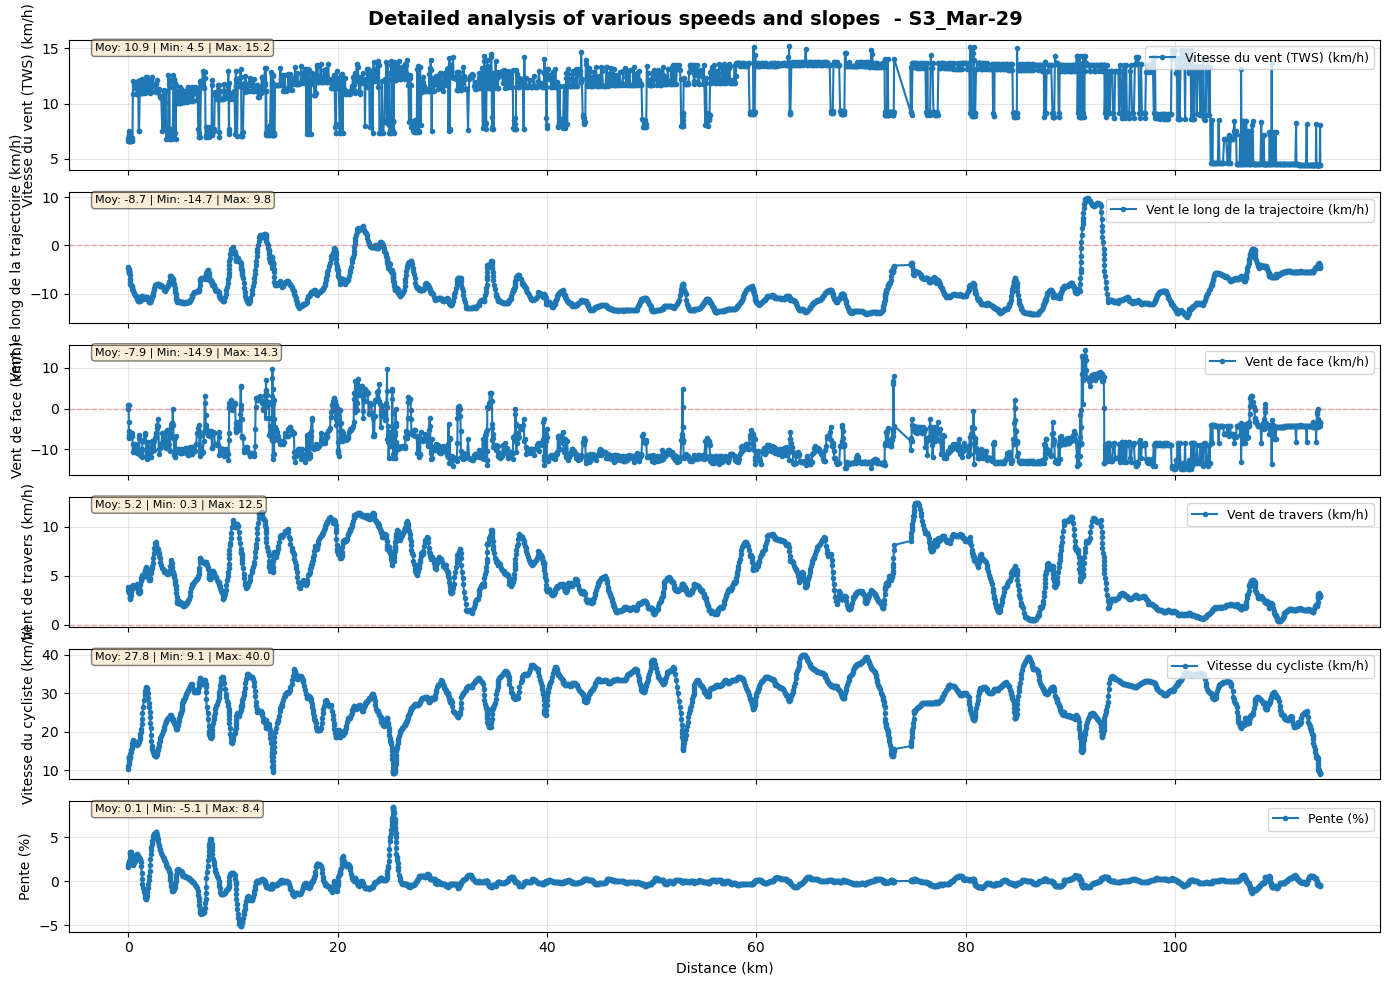

In [10]:
fig1, axes1 = plot_segments_evolution(
    results_timestamps_smooth, 
    attributes=['tws', 'wind_along', 'headwind', 'crosswind', 'speed_m_s', 'slope'],
    x_axis='distance',
    title=f'Detailed analysis of various speeds and slopes  - {pathbase}_{ct_start}'
)
plt.show()

### 8.2 Speed comparison with/without wind

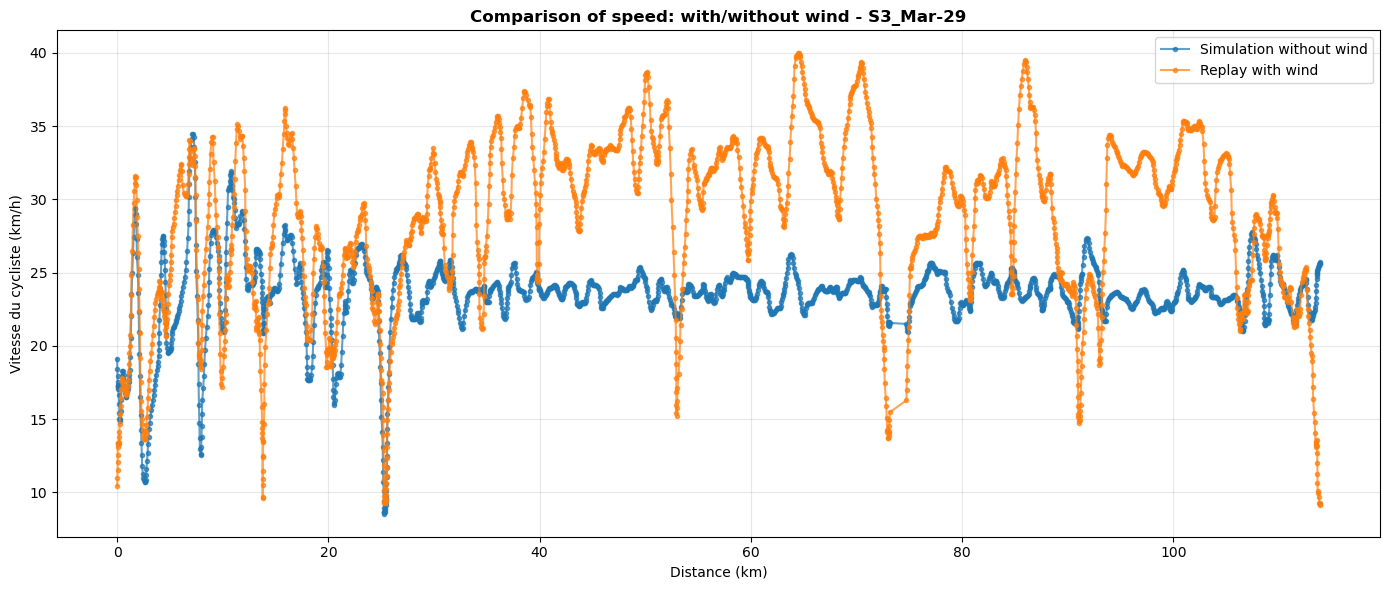

In [11]:

fig, ax = compare_scenarios(
    [results_nowind_smooth, results_timestamps_smooth],
    labels=['Simulation without wind', 'Replay with wind'],
    attribute='speed_m_s',
    x_axis='distance',
    title=f'Comparison of speed: with/without wind - {pathbase}_{ct_start}'
)
plt.show()

### 8.3 Real and virtual elevation profile

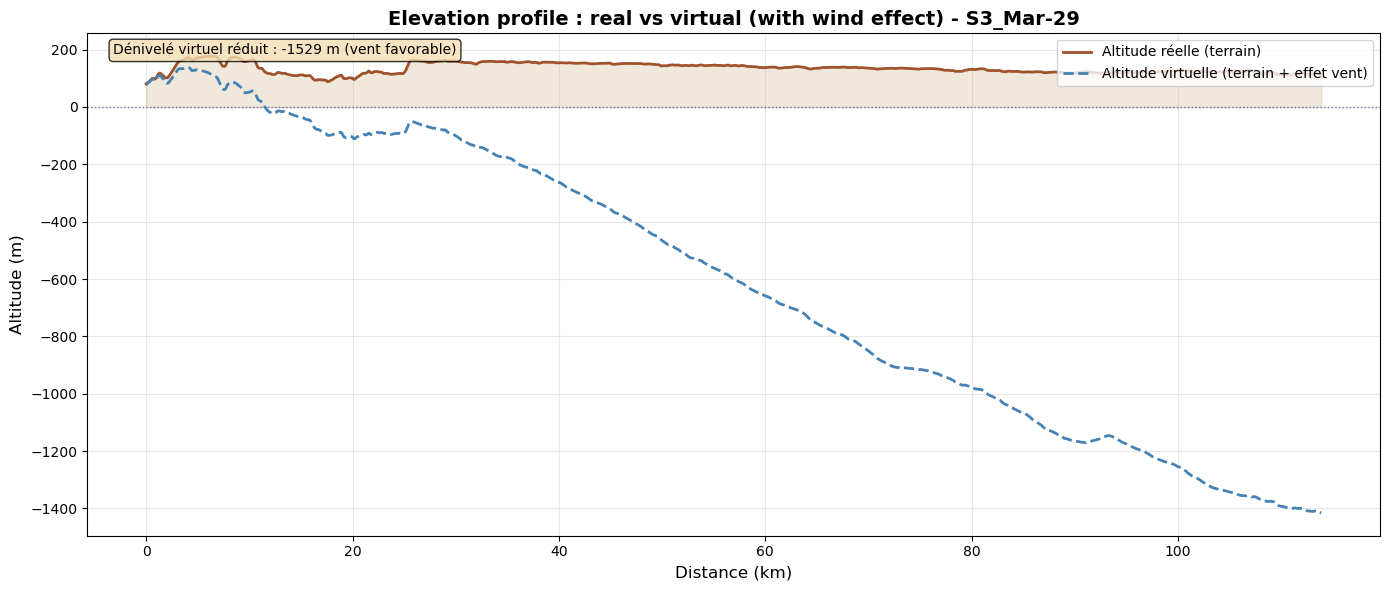

In [12]:

fig,ax = plot_elevation_profile (
    results_timestamps_smooth,
    title=f'Elevation profile : real vs virtual (with wind effect) - {pathbase}_{ct_start}'
)
plt.show()

### 8.4 Changes over time in wind speed and power

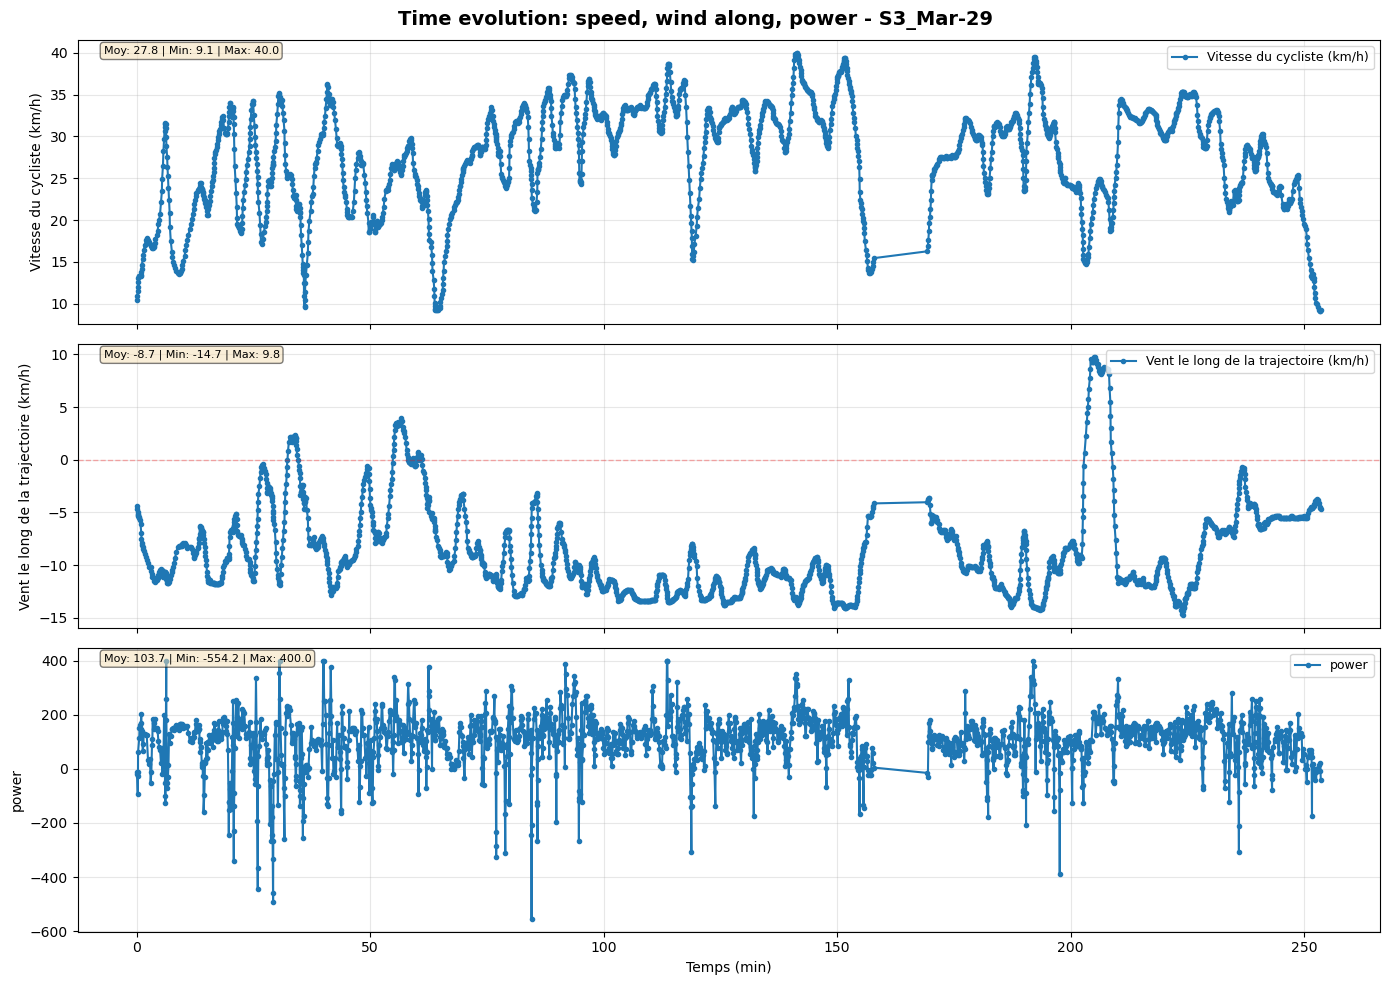

In [13]:
fig, axes = plot_segments_evolution(
    results_timestamps_smooth, 
    attributes=['speed_m_s', 'wind_along', 'power'],
    x_axis='time',
    title=f'Time evolution: speed, wind along, power - {pathbase}_{ct_start}'
)
plt.show()

### 8.5 Wind rose

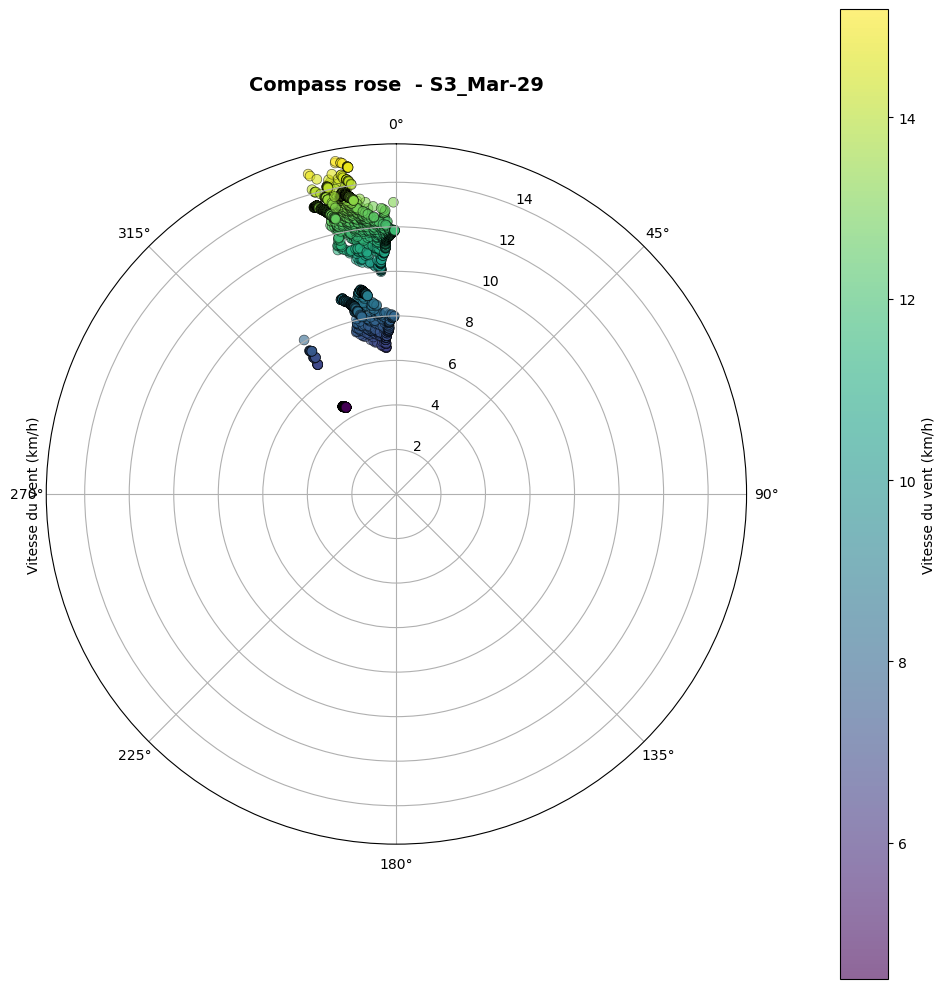

In [14]:

fig, ax = plot_wind_rose(
    results_timestamps_smooth,
    title=f'Compass rose  - {pathbase}_{ct_start}'
)
plt.show()

## 9. Experimental: Interactive map generation

This feature generates an HTML page containing:

- at the top, the colored route with wind levels.
- at the bottom, the elevation profile (real and virtual). Movement along this profile is synchronized with the top section.
- an optional animation for automatic navigation.

Open the generated page in a browser (you can also launch an HTTP server with `python -m http.server 8080`).





In [15]:
interactive_html = create_interactive_map(
    results_timestamps_smooth,
    output_file= home+"./data/html/"+f'interactive_map_{pathbase}_{ct_start}.html',
    title=f'Interactive Map - {pathbase}_{ct_start}',
)
print(f"Interactive map saved to home/data/html/interactive_map_{pathbase}_{ct_start}.html")

Interactive map saved to home/data/html/interactive_map_S3_Mar-29.html


### Screenshot of the interactive map 

![Carte interactive](/_static/generated_map.png)